In [ ]:
!pip install timm transformers

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from transformers import BertModel, BertTokenizer

print("GPU:", torch.cuda.is_available())

GPU: False


#BLIP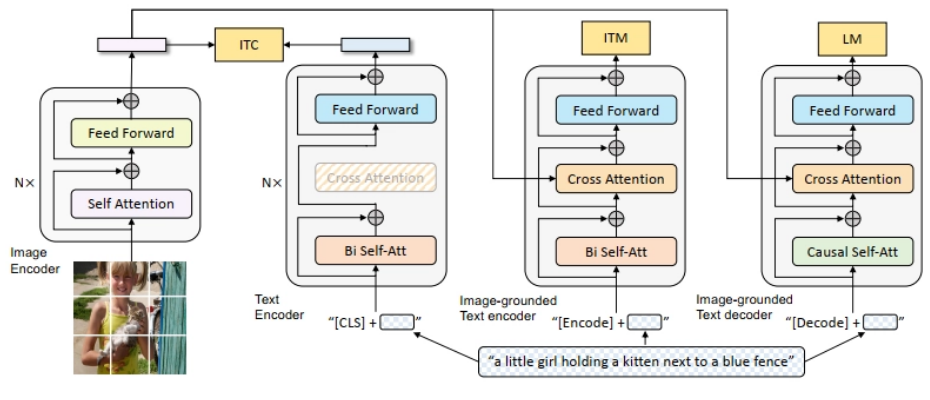

In [ ]:
# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        # ViT 불러오기 (미니버전)
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=True
        )
        # 출력 차원 맞추기
        self.proj = nn.Linear(192, embed_dim)

    def forward(self, image):
        feat = self.vit.forward_features(image)
        feat = feat[:, 0, :]  # CLS 토큰만 사용
        feat = self.proj(feat)
        # 정규화 (ITC에서 유사도 계산할 때 필요)
        feat = F.normalize(feat, dim=-1)
        return feat

In [ ]:
# Text Encoder
class TextEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.proj = nn.Linear(768, embed_dim)

    def forward(self, input_ids, attention_mask):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # CLS 토큰 출력 사용
        feat = out.last_hidden_state[:, 0, :]
        feat = self.proj(feat)
        feat = F.normalize(feat, dim=-1)
        return feat

In [ ]:
# ITC Loss
def itc_loss(image_feat, text_feat, temperature=0.07):
    # 유사도 행렬 계산
    sim_i2t = image_feat @ text_feat.T / temperature
    sim_t2i = text_feat @ image_feat.T / temperature

    # 정답 레이블 (대각선이 맞는 쌍)
    labels = torch.arange(image_feat.shape[0])

    # 양방향 loss
    loss_i2t = F.cross_entropy(sim_i2t, labels)
    loss_t2i = F.cross_entropy(sim_t2i, labels)

    return (loss_i2t + loss_t2i) / 2

In [ ]:
# ITC 동작연결
# 모델 생성
image_encoder = ImageEncoder()
text_encoder = TextEncoder()
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 가짜 데이터로 동작 확인
dummy_image = torch.randn(2, 3, 224, 224)  # 이미지 2장
dummy_text = ["a dog running", "a cat sitting"]

# 토크나이징
tokens = tokenizer(
    dummy_text,
    return_tensors='pt',
    padding=True
)

# 인코딩
image_feat = image_encoder(dummy_image)
text_feat = text_encoder(
    tokens['input_ids'],
    tokens['attention_mask']
)

# ITC Loss 계산
loss = itc_loss(image_feat, text_feat)
print("image_feat shape:", image_feat.shape)
print("text_feat shape:", text_feat.shape)
print("ITC Loss:", loss.item())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

image_feat shape: torch.Size([2, 256])
text_feat shape: torch.Size([2, 256])
ITC Loss: 0.660791277885437


ITC : 이미지, 텍스트 따로 인코딩 후 비교 (빠름)

ITM : 이미지 보면서 텍스트 동시 처리 (정밀)
      → 이 둘이 진짜 맞는 쌍인지 Yes/No 판단

In [ ]:
# cross attention 모듈
class CrossAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, text_feat, image_feat):
        # 텍스트가 이미지를 참고하는 것
        # Query=텍스트, Key/Value=이미지
        out, _ = self.attn(
            query=text_feat,
            key=image_feat,
            value=image_feat
        )
        # 잔차 연결
        out = self.norm(out + text_feat)
        return out

In [ ]:
# ITM Head
class ITMHead(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        # Yes/No 이진 분류
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, feat):
        return self.classifier(feat)

In [ ]:
# ITM Loss
def itm_loss(image_feat, text_feat, cross_attn, itm_head):
    batch_size = image_feat.shape[0]

    # image_feat를 텍스트 길이에 맞게 unsqueeze
    image_feat_expanded = image_feat.unsqueeze(1)  # [B, 1, 256]
    text_feat_expanded = text_feat.unsqueeze(1)    # [B, 1, 256]

    # Positive 쌍 (맞는 이미지-텍스트 쌍)
    pos_feat = cross_attn(text_feat_expanded, image_feat_expanded)
    pos_feat = pos_feat.squeeze(1)  # [B, 256]
    pos_logits = itm_head(pos_feat)  # [B, 2]
    pos_labels = torch.ones(batch_size, dtype=torch.long)  # 1 = 맞는 쌍

    # Negative 쌍 (틀린 이미지-텍스트 쌍)
    # 이미지를 한 칸 밀어서 틀린 쌍 만들기
    neg_image_feat = torch.roll(image_feat, 1, dims=0)
    neg_image_feat_expanded = neg_image_feat.unsqueeze(1)

    neg_feat = cross_attn(text_feat_expanded, neg_image_feat_expanded)
    neg_feat = neg_feat.squeeze(1)
    neg_logits = itm_head(neg_feat)  # [B, 2]
    neg_labels = torch.zeros(batch_size, dtype=torch.long)  # 0 = 틀린 쌍

    # Positive + Negative 합쳐서 Loss 계산
    logits = torch.cat([pos_logits, neg_logits], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)

    loss = F.cross_entropy(logits, labels)
    return loss

In [ ]:
# ITM 동작연
# 모듈 생성
cross_attn = CrossAttention()
itm_head = ITMHead()

# 앞에서 만든 image_feat, text_feat 그대로 사용
itm = itm_loss(image_feat, text_feat, cross_attn, itm_head)
print("ITM Loss:", itm.item())

# ITC + ITM 합산
total_loss = loss + itm  # loss는 아까 구한 ITC loss
print("Total Loss (ITC + ITM):", total_loss.item())

ITM Loss: 0.7188274264335632
Total Loss (ITC + ITM): 1.3796186447143555


ITC : 이미지-텍스트 관련있는지 판단

ITM : 이미지-텍스트 정밀 매칭

LM  : 이미지 보고 텍스트 생성 (캡션 생성)
      → 실제로 "a dog running" 같은 문장 만들어내는 것

In [ ]:
# Text Decoder
class TextDecoder(nn.Module):
    def __init__(self, embed_dim=256, vocab_size=30522, num_heads=4):
        super().__init__()

        # 단어 임베딩
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Causal Self Attention (앞 단어만 보기)
        self.self_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # Cross Attention (이미지 참고)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # Feed Forward
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)

        # 최종 단어 예측
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, input_ids, image_feat):
        seq_len = input_ids.shape[1]

        # 단어를 벡터로 변환
        x = self.embedding(input_ids)  # [B, seq_len, 256]

        # Causal mask (앞 단어만 보도록)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len), diagonal=1
        ).bool()

        # Causal Self Attention
        self_out, _ = self.self_attn(x, x, x, attn_mask=causal_mask)
        x = self.norm1(x + self_out)

        # Cross Attention (이미지 참고)
        image_feat_expanded = image_feat.unsqueeze(1)  # [B, 1, 256]
        cross_out, _ = self.cross_attn(x, image_feat_expanded, image_feat_expanded)
        x = self.norm2(x + cross_out)

        # Feed Forward
        ff_out = self.ff(x)
        x = self.norm3(x + ff_out)

        # 단어 예측
        logits = self.lm_head(x)  # [B, seq_len, vocab_size]
        return logits

In [ ]:
# LM Loss
def lm_loss(image_feat, input_ids, decoder):
    # input_ids에서
    # 입력 : 앞부분 (a dog)
    # 정답 : 뒷부분 (dog running)
    decoder_input = input_ids[:, :-1]   # 마지막 단어 제외
    decoder_label = input_ids[:, 1:]    # 첫 단어 제외

    # 디코더 실행
    logits = decoder(decoder_input, image_feat)

    # Loss 계산
    loss = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        decoder_label.reshape(-1),
        ignore_index=0  # 패딩 무시
    )
    return loss

In [ ]:
# LM 동작연결
# 디코더 생성
decoder = TextDecoder()

# LM Loss 계산
lm = lm_loss(image_feat, tokens['input_ids'], decoder)
print("LM Loss:", lm.item())

# 최종 전체 Loss
total_loss = loss + itm + lm
print("Total Loss (ITC + ITM + LM):", total_loss.item())

LM Loss: 10.329879760742188
Total Loss (ITC + ITM + LM): 11.709498405456543
